In [4]:
# --- 导入必要的库 ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ==============================================================================
# 1. PyTorch 版本的 DNN 模型 (与您提供的完全相同)
# ==============================================================================
class ResidualDNN(nn.Module):
    # (您的ResidualDNN类代码，无需任何改动)
    def __init__(self, input_dim, output_dim, layers_config=[256, 128, 64],
                 dropout_rate=0.2, l2_regularization=1e-4):
        super(ResidualDNN, self).__init__()
        layers_list = []; current_dim = input_dim
        for i, units in enumerate(layers_config):
            block = nn.Sequential(nn.Linear(current_dim, units), nn.LayerNorm(units), nn.LeakyReLU(0.2), nn.Dropout(dropout_rate))
            layers_list.append(block)
            is_residual = (i != 0 and current_dim == units)
            layers_list.append(is_residual)
            current_dim = units
        self.hidden_layers = nn.ModuleList([layer for layer in layers_list if isinstance(layer, nn.Module)])
        self.residual_flags = [flag for flag in layers_list if isinstance(flag, bool)]
        self.output_layer = nn.Linear(current_dim, output_dim)
    def forward(self, x):
        for i, layer in enumerate(self.hidden_layers):
            x_prev_layer = x; x = layer(x)
            if self.residual_flags[i]: x = x + x_prev_layer
        x = self.output_layer(x); return x




# ==============================================================================
# 3. 加载并处理POLDER-MERRA2大数据集
# ==============================================================================
try:
    data = pd.read_csv('/media/amers/SSD_part1/whx/ResNet_code/dynamic_prior/Merra2_training_dataset_new2.csv')
    print("\nMERRA-2大数据集加载成功！")
except FileNotFoundError:
    print("错误：找不到MERRA-2匹配数据集！"); exit()

data = data.sample(frac=1, random_state=42).reset_index(drop=True)
#将elev转换为km
data['elev'] = data['elev'] / 1000  
# ==============================================================================
# 4. 准备“比例”预测任务的特征(X)和目标(y)
# ==============================================================================
print("\n--- 准备用于'比例'预测的数据 ---")
component_columns = ['bc_vol', 'urban_vol', 'sea_vol', 'dust_vol','AOD_550nm','SSA_550nm']
#检查目标列是否存在
missing_columns = [col for col in component_columns if col not in data.columns]
if missing_columns:
    print(f"错误：以下目标列在数据集中缺失: {missing_columns}"); exit()
y_fractions = data[component_columns].values # <-- 使用 .values 获取Numpy数组

# --- B. 创建特征矩阵 ---
# 1. 选取纯POLDER观测和地理特征 (使用严格排序)
ordered_feature_columns = []
base_features = ['elev']
ordered_feature_columns.extend(base_features)
obs_sequence = ['sza', 'vza', 'phi', 'TOA443', 'TOA490', 'DolP490', 'TOA565', 'TOA670', 'DolP670', 'TOA865', 'DolP865', 'TOA1020']
for i in range(2, 13):
    for name in obs_sequence:
        ordered_feature_columns.append(f'{name}_ang{i}')
X_base = data[ordered_feature_columns].values # <-- 使用 .values 获取Numpy数组

X_for_fractions = X_base
print(f"新特征已添加。最终特征数量: {X_for_fractions.shape[1]}")

# --- C. 划分训练/验证/测试集 ---
X_train, X_temp, y_train, y_temp = train_test_split(X_for_fractions, y_fractions, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# --- D. 为新的X和y创建并应用新的Scalers ---
print("\n--- 正在为'比例'任务创建和应用新的Scalers ---")
scaler_x_frac = StandardScaler()
X_train_scaled = scaler_x_frac.fit_transform(X_train)
X_val_scaled = scaler_x_frac.transform(X_val)
X_test_scaled = scaler_x_frac.transform(X_test)

# 注意：比例y通常不需要标准化，因为它们的值域都在0-1之间。但为了代码一致性，我们仍然这样做。
scaler_y_frac = StandardScaler()
y_train_scaled = scaler_y_frac.fit_transform(y_train)
y_val_scaled = scaler_y_frac.transform(y_val)

# --- E. 转换为PyTorch Tensors和DataLoader ---
BATCH_SIZE = 3000
train_dataset = TensorDataset(torch.from_numpy(X_train_scaled).float(), torch.from_numpy(y_train_scaled).float())
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataset = TensorDataset(torch.from_numpy(X_val_scaled).float(), torch.from_numpy(y_val_scaled).float())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# ==============================================================================
# 5. 训练“比例”预测神经网络
# ==============================================================================
print("\n--- 开始训练'比例'预测神经网络 ---")
input_dim_frac = X_train_scaled.shape[1]
output_dim_frac = y_train_scaled.shape[1]

# 实例化一个新模型用于比例预测
fraction_model = ResidualDNN(
    input_dim=input_dim_frac, output_dim=output_dim_frac,
    layers_config=[1024, 512, 256, 128], dropout_rate=0.01, l2_regularization=1e-5
).to(device)
print(device)

# 定义优化器和损失函数
optimizer = optim.AdamW(fraction_model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=10)
loss_fn = nn.MSELoss()

# --- 训练循环 ---
EPOCHS = 1200; PATIENCE = 25
best_val_loss = float('inf'); patience_counter = 0
history = {'loss': [], 'val_loss': []}

for epoch in range(EPOCHS):
    # (训练和验证循环与之前完全相同)
    fraction_model.train(); running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device); optimizer.zero_grad()
        outputs = fraction_model(inputs); loss = loss_fn(outputs, targets)
        loss.backward(); optimizer.step(); running_loss += loss.item()
    avg_train_loss = running_loss / len(train_loader); history['loss'].append(avg_train_loss)
    
    fraction_model.eval(); val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = fraction_model(inputs); loss = loss_fn(outputs, targets)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader); history['val_loss'].append(avg_val_loss)
    
    print(f"Fraction Model Epoch {epoch+1}/{EPOCHS} - Loss: {avg_train_loss:.6f} - Val_Loss: {avg_val_loss:.6f}")
    scheduler.step(avg_val_loss)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss; patience_counter = 0
        torch.save(fraction_model.state_dict(), 'vc_best_model_polder.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}"); break

# ==============================================================================
# 6. 保存最终的“比例”模型和相关Scalers
# ==============================================================================
print("\n--- 加载性能最佳的'比例'模型并保存 ---")
fraction_model.load_state_dict(torch.load('vc_best_model_polder.pth'))

FRAC_MODEL_PATH = 'vc_model_polder.pth'
SCALER_X_FRAC_PATH = 'dnn_feature_scaler_vc_polder.joblib'
SCALER_Y_FRAC_PATH = 'dnn_target_scaler_vc_polder.joblib'

torch.save(fraction_model.state_dict(), FRAC_MODEL_PATH)
joblib.dump(scaler_x_frac, SCALER_X_FRAC_PATH)
joblib.dump(scaler_y_frac, SCALER_Y_FRAC_PATH)
print("比例模型和相关Scalers保存成功！")


MERRA-2大数据集加载成功！

--- 准备用于'比例'预测的数据 ---
新特征已添加。最终特征数量: 133

--- 正在为'比例'任务创建和应用新的Scalers ---

--- 开始训练'比例'预测神经网络 ---
cuda
Fraction Model Epoch 1/1200 - Loss: 0.533957 - Val_Loss: 0.448492
Fraction Model Epoch 2/1200 - Loss: 0.430681 - Val_Loss: 0.402124
Fraction Model Epoch 3/1200 - Loss: 0.401006 - Val_Loss: 0.382269
Fraction Model Epoch 4/1200 - Loss: 0.382876 - Val_Loss: 0.370006
Fraction Model Epoch 5/1200 - Loss: 0.369677 - Val_Loss: 0.356912
Fraction Model Epoch 6/1200 - Loss: 0.360713 - Val_Loss: 0.344784
Fraction Model Epoch 7/1200 - Loss: 0.352665 - Val_Loss: 0.346497
Fraction Model Epoch 8/1200 - Loss: 0.344863 - Val_Loss: 0.336496
Fraction Model Epoch 9/1200 - Loss: 0.339234 - Val_Loss: 0.331614
Fraction Model Epoch 10/1200 - Loss: 0.334214 - Val_Loss: 0.329952
Fraction Model Epoch 11/1200 - Loss: 0.330359 - Val_Loss: 0.323203
Fraction Model Epoch 12/1200 - Loss: 0.325462 - Val_Loss: 0.317498
Fraction Model Epoch 13/1200 - Loss: 0.321946 - Val_Loss: 0.313561
Fraction Model E


==================== 准备阶段：加载所有模型和Scalers ====================
体积浓度(VC)模型及相关Scalers加载成功！

已准备 66396 条测试样本进行验证。

--- 开始执行预测流水线 ---
预测完成！

--- 在测试集上的评估结果 ---
  bc_vol: R² = 0.8300, RMSE = 0.0043


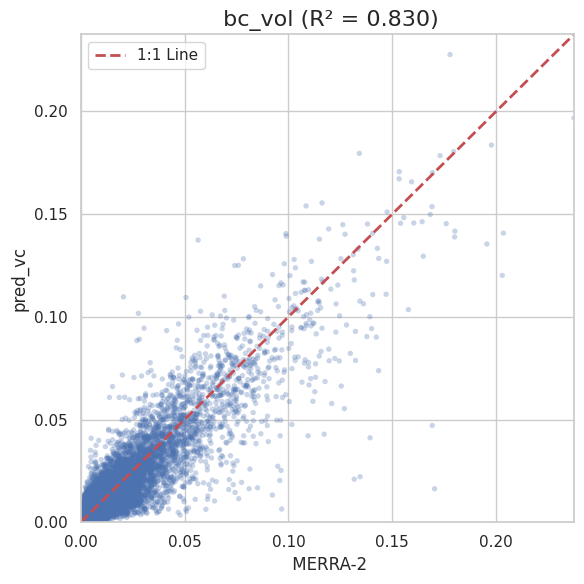

  urban_vol: R² = 0.7055, RMSE = 0.0124


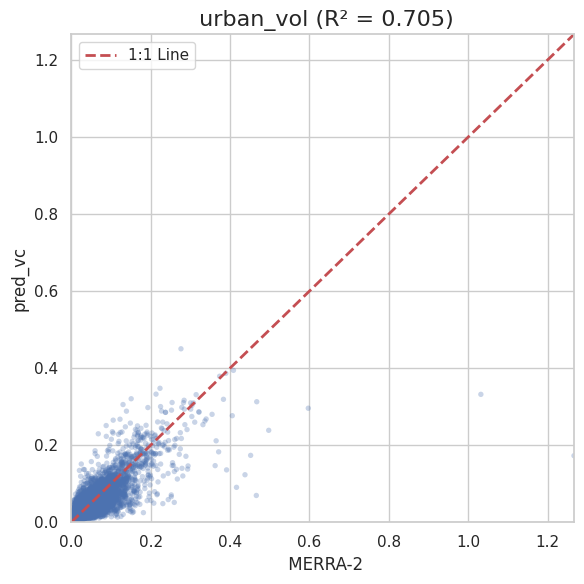

  sea_vol: R² = 0.6257, RMSE = 0.0057


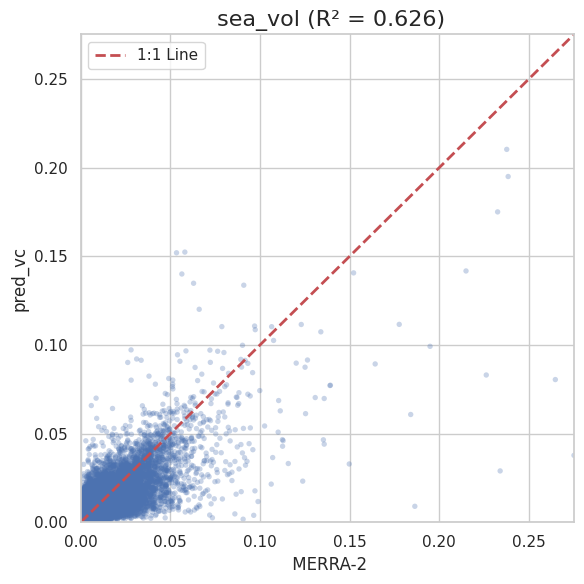

  dust_vol: R² = 0.8431, RMSE = 0.0546


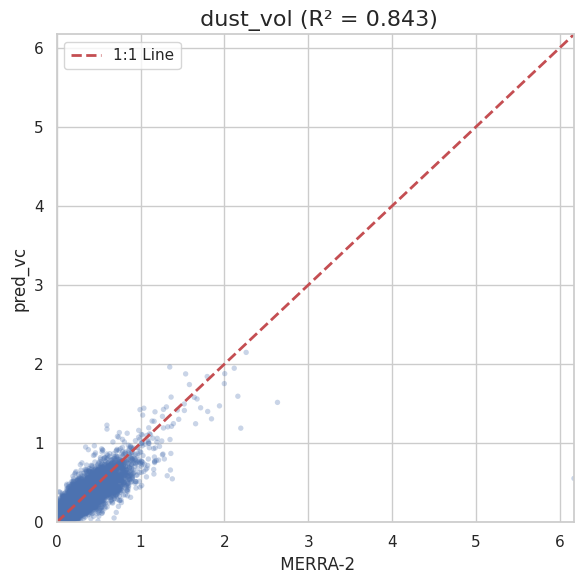

  AOD_550nm: R² = 0.8327, RMSE = 0.0795


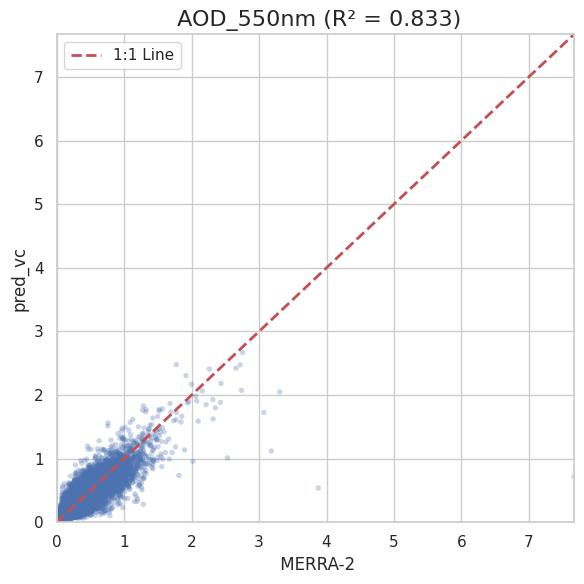

  SSA_550nm: R² = 0.7186, RMSE = 0.0141


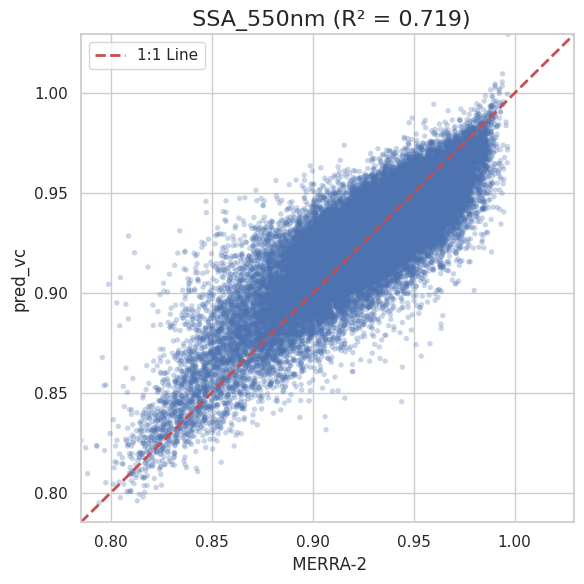

In [6]:
# --- 导入必要的库 ---
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. 定义与训练时结构完全相同的模型类
# ==============================================================================
class ResidualDNN(nn.Module):
    # (您的ResidualDNN类定义，确保与训练时完全相同)
    def __init__(self, input_dim, output_dim, layers_config=[256, 128, 64],
                 dropout_rate=0.2, l2_regularization=1e-4):
        super(ResidualDNN, self).__init__()
        layers_list = []; current_dim = input_dim
        for i, units in enumerate(layers_config):
            block = nn.Sequential(nn.Linear(current_dim, units), nn.LayerNorm(units), nn.LeakyReLU(0.2), nn.Dropout(dropout_rate))
            layers_list.append(block)
            is_residual = (i != 0 and current_dim == units)
            layers_list.append(is_residual)
            current_dim = units
        self.hidden_layers = nn.ModuleList([layer for layer in layers_list if isinstance(layer, nn.Module)])
        self.residual_flags = [flag for flag in layers_list if isinstance(flag, bool)]
        self.output_layer = nn.Linear(current_dim, output_dim)
    def forward(self, x):
        for i, layer in enumerate(self.hidden_layers):
            x_prev_layer = x; x = layer(x)
            if self.residual_flags[i]: x = x + x_prev_layer
        x = self.output_layer(x); return x

# ==============================================================================
# 2. 加载所有必需的模型和Scalers
# ==============================================================================
print(f"\n{'='*20} 准备阶段：加载所有模型和Scalers {'='*20}")
device = torch.device("cpu")


input_dim_aod = 133


# --- B. 加载您刚刚训练的模型 (我们称之为VC模型) ---
VC_MODEL_PATH = '/media/amers/SSD_part1/whx/ResNet_forPolder/dynamic_prior/vc_model_polder.pth'
SCALER_X_VC_PATH = '/media/amers/SSD_part1/whx/ResNet_forPolder/dynamic_prior/dnn_feature_scaler_vc_polder.joblib'
SCALER_Y_VC_PATH = '/media/amers/SSD_part1/whx/ResNet_forPolder/dynamic_prior/dnn_target_scaler_vc_polder.joblib'
input_dim_vc = input_dim_aod 
output_dim_vc = 6
vc_model = ResidualDNN(input_dim_vc, output_dim_vc, layers_config=[1024, 512, 256, 128]).to(device)
vc_model.load_state_dict(torch.load(VC_MODEL_PATH, map_location=device))
vc_model.eval()
scaler_x_vc = joblib.load(SCALER_X_VC_PATH)
scaler_y_vc = joblib.load(SCALER_Y_VC_PATH)
print("体积浓度(VC)模型及相关Scalers加载成功！")

# ==============================================================================
# 3. 加载并准备MERRA2测试数据
# ==============================================================================
try:
    data_raw = pd.read_csv('/media/amers/SSD_part1/whx/ResNet_code/dynamic_prior/Merra2_training_dataset_new2.csv')
    data = data_raw.sample(frac=1, random_state=42).reset_index(drop=True)
except FileNotFoundError:
    print("错误：找不到MERRA-2匹配数据集！"); exit()

data['elev'] = data['elev'] / 1000
# --- 准备特征和目标 ---
component_columns = ['bc_vol', 'urban_vol', 'sea_vol', 'dust_vol','AOD_550nm','SSA_550nm']
ordered_feature_columns = []
base_features = ['elev']
ordered_feature_columns.extend(base_features)
obs_sequence = ['sza', 'vza', 'phi', 'TOA443', 'TOA490', 'DolP490', 'TOA565', 'TOA670', 'DolP670', 'TOA865', 'DolP865', 'TOA1020']
for i in range(2, 13):
    for name in obs_sequence:
        ordered_feature_columns.append(f'{name}_ang{i}')

X_base = data[ordered_feature_columns]
y_true_vc = data[component_columns]

# --- 划分数据集，确保使用与训练时完全相同的测试集 ---
_, X_temp, _, y_temp = train_test_split(X_base, y_true_vc, test_size=0.3, random_state=42)
_, X_test_base, _, y_test = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)
print(f"\n已准备 {len(X_test_base)} 条测试样本进行验证。")

# ==============================================================================
# 4. 执行预测流水线
# ==============================================================================
print("\n--- 开始执行预测流水线 ---")



# --- Step 2: 构建VC模型的输入 ---
X_test_for_vc = X_test_base.values

# --- Step 3: 使用VC模型预测体积浓度 ---
X_test_scaled_for_vc = scaler_x_vc.transform(X_test_for_vc)
X_test_tensor_vc = torch.from_numpy(X_test_scaled_for_vc).float().to(device)
with torch.no_grad():
    predicted_vc_scaled = vc_model(X_test_tensor_vc).cpu().numpy()
predicted_vc = scaler_y_vc.inverse_transform(predicted_vc_scaled)
predicted_vc[predicted_vc < 0] = 0 # 确保物理合理性

y_pred_df = pd.DataFrame(predicted_vc, columns=component_columns, index=y_test.index)
print("预测完成！")

# ==============================================================================
# 5. 评估与可视化 (简单散点图)
# ==============================================================================
print("\n--- 在测试集上的评估结果 ---")
sns.set_theme(style="whitegrid")

for target in component_columns:
    true_values = y_test[target]
    pred_values = y_pred_df[target]
    
    r2 = r2_score(true_values, pred_values)
    rmse = np.sqrt(mean_squared_error(true_values, pred_values))
    
    print(f"  {target}: R² = {r2:.4f}, RMSE = {rmse:.4f}")
    
    # --- 绘制简单散点图 ---
    plt.figure(figsize=(6, 6))
    plt.scatter(true_values, pred_values, alpha=0.3, s=15, edgecolor='none')
    
    # 添加1:1线
    lims = [
        min(true_values.min(), pred_values.min()),
        max(true_values.max(), pred_values.max())
    ]
    plt.plot(lims, lims, 'r--', linewidth=2, label='1:1 Line')
    
    plt.title(f' {target} (R² = {r2:.3f})', fontsize=16)
    plt.xlabel(' MERRA-2', fontsize=12)
    plt.ylabel('pred_vc', fontsize=12)
    plt.xlim(lims)
    plt.ylim(lims)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [11]:
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import joblib
from tqdm import tqdm

# ==============================================================================
# 1. 定义与训练时结构完全相同的模型类
# ==============================================================================
class ResidualDNN(nn.Module):
    def __init__(self, input_dim, output_dim, layers_config=[256, 128, 64],
                 dropout_rate=0.2, l2_regularization=1e-4):
        super(ResidualDNN, self).__init__()
        layers_list = []; current_dim = input_dim
        for i, units in enumerate(layers_config):
            block = nn.Sequential(
                nn.Linear(current_dim, units), 
                nn.LayerNorm(units), 
                nn.LeakyReLU(0.2), 
                nn.Dropout(dropout_rate)
            )
            layers_list.append(block)
            is_residual = (i != 0 and current_dim == units)
            layers_list.append(is_residual)
            current_dim = units
        self.hidden_layers = nn.ModuleList([layer for layer in layers_list if isinstance(layer, nn.Module)])
        self.residual_flags = [flag for flag in layers_list if isinstance(flag, bool)]
        self.output_layer = nn.Linear(current_dim, output_dim)
        
    def forward(self, x):
        for i, layer in enumerate(self.hidden_layers):
            x_prev_layer = x
            x = layer(x)
            if self.residual_flags[i]: 
                x = x + x_prev_layer
        x = self.output_layer(x)
        return x

# ==============================================================================
# 2. 配置路径 (请根据你的实际路径修改)
# ==============================================================================
# 输入与输出 CSV 路径
INPUT_CSV_PATH = '/media/amers/SSD_part1/whx/ResNet_forPolder/polder_aeronet_matched_dataset_ready.csv'
OUTPUT_CSV_PATH = '/media/amers/SSD_part1/whx/ResNet_forPolder/polder_aeronet_matched_dataset_withPrior.csv'

# 模型与 Scaler 路径
VC_MODEL_PATH = '/media/amers/SSD_part1/whx/ResNet_forPolder/dynamic_prior/vc_model_polder.pth'
SCALER_X_VC_PATH = '/media/amers/SSD_part1/whx/ResNet_forPolder/dynamic_prior/dnn_feature_scaler_vc_polder.joblib'
SCALER_Y_VC_PATH = '/media/amers/SSD_part1/whx/ResNet_forPolder/dynamic_prior/dnn_target_scaler_vc_polder.joblib'

# ==============================================================================
# 3. 加载模型和 Scalers
# ==============================================================================
print(f"\n{'='*20} 准备阶段：加载模型和Scalers {'='*20}")
device = torch.device("cpu")

input_dim_vc = 133  # 1 (elev) + 11 * 12 (角度特征)
output_dim_vc = 6

vc_model = ResidualDNN(input_dim_vc, output_dim_vc, layers_config=[1024, 512, 256, 128]).to(device)
vc_model.load_state_dict(torch.load(VC_MODEL_PATH, map_location=device))
vc_model.eval()

scaler_x_vc = joblib.load(SCALER_X_VC_PATH)
scaler_y_vc = joblib.load(SCALER_Y_VC_PATH)
print("体积浓度与AOD/SSA预测模型及相关Scalers加载成功！")

# ==============================================================================
# 4. 读取数据并提取特征
# ==============================================================================
print(f"\n{'='*20} 开始处理 CSV 数据 {'='*20}")
try:
    df = pd.read_csv(INPUT_CSV_PATH)
    print(f"成功读取 CSV 文件，共 {len(df)} 条记录。")
except FileNotFoundError:
    print(f"错误：找不到文件 {INPUT_CSV_PATH}！")
    exit()

features_list = []

for index, row in tqdm(df.iterrows(), total=len(df), desc="提取特征"):
    # 1. 基础特征：高程 (注意训练时除以了 1000)
    elev_km = row['elev'] / 1000.0 if pd.notna(row['elev']) else 0.0
    features = [elev_km]
    
    # 2. 角度特征：循环 ang0 到 ang10 (共 11 个角度)
    for ang_idx in range(11):
        sza = row.get(f'sza_ang{ang_idx}')
        
        # 如果该角度无观测，用 0 填充 12 个变量
        if pd.isna(sza) or sza <= 0:
            features.extend([0.0] * 12)
            continue
            
        vza = row.get(f'vza_ang{ang_idx}', 0.0)
        phi = row.get(f'phi_ang{ang_idx}', 0.0)
        
        # 计算 cos(sza) 用于 TOA 转换
        cos_sza = np.cos(np.deg2rad(sza))
        if cos_sza < 1e-6:
            cos_sza = 1.0
            
        # 提取并计算无偏振通道的 TOA
        I443 = row.get(f'I443_ang{ang_idx}', 0.0)
        TOA443 = I443 / cos_sza if pd.notna(I443) and I443 > 0 else 0.0
        
        I565 = row.get(f'I565_ang{ang_idx}', 0.0)
        TOA565 = I565 / cos_sza if pd.notna(I565) and I565 > 0 else 0.0
        
        I1020 = row.get(f'I1020_ang{ang_idx}', 0.0)
        TOA1020 = I1020 / cos_sza if pd.notna(I1020) and I1020 > 0 else 0.0
        
        # 提取并计算有偏振通道的 TOA 和 DOLP
        def get_toa_dolp(wl):
            I = row.get(f'I{wl}_ang{ang_idx}')
            Q = row.get(f'Q{wl}_ang{ang_idx}')
            U = row.get(f'U{wl}_ang{ang_idx}')
            
            if pd.isna(I) or I <= 1e-6:
                return 0.0, 0.0
                
            Q_val = Q if pd.notna(Q) else 0.0
            U_val = U if pd.notna(U) else 0.0
            
            TOA = I / cos_sza
            DOLP = np.sqrt(Q_val**2 + U_val**2) / I
            return TOA, DOLP

        TOA490, DOLP490 = get_toa_dolp('490')
        TOA670, DOLP670 = get_toa_dolp('670')
        TOA865, DOLP865 = get_toa_dolp('865')
        
        # 严格按照训练时的 12 个变量顺序追加
        features.extend([sza, vza, phi, TOA443, TOA490, DOLP490, TOA565, TOA670, DOLP670, TOA865, DOLP865, TOA1020])
        
    features_list.append(features)

# ==============================================================================
# 5. 执行批量推理
# ==============================================================================
print(f"\n{'='*20} 开始模型推理 {'='*20}")
X_numpy = np.array(features_list)

# 特征缩放
X_scaled = scaler_x_vc.transform(X_numpy)
X_tensor = torch.from_numpy(X_scaled).float().to(device)

# 模型预测
with torch.no_grad():
    y_pred_scaled = vc_model(X_tensor).cpu().numpy()

# 反归一化
y_pred = scaler_y_vc.inverse_transform(y_pred_scaled)

# 物理约束：保证预测值非负
y_pred[y_pred < 0] = 0.0 

# ==============================================================================
# 6. 保存结果到 DataFrame
# ==============================================================================
# 根据你的训练顺序：['bc_vol', 'urban_vol', 'sea_vol', 'dust_vol', 'AOD_550nm', 'SSA_550nm']
df['Pred_vc_BB'] = y_pred[:, 0]
df['Pred_vc_Urban'] = y_pred[:, 1]
df['Pred_vc_Ocean'] = y_pred[:, 2]
df['Pred_vc_Dust'] = y_pred[:, 3]

# 核心需求：保存 AOD 和 SSA
df['Pred_AOD_550nm'] = y_pred[:, 4]
df['Pred_SSA_550nm'] = y_pred[:, 5]

# 保存到新的 CSV 文件
df.to_csv(OUTPUT_CSV_PATH, index=False)
print(f"\n推理完成！结果已成功保存至：\n{OUTPUT_CSV_PATH}")
print("新增列：'Pred_vc_BB', 'Pred_vc_Urban', 'Pred_vc_Ocean', 'Pred_vc_Dust', 'Pred_AOD_550nm', 'Pred_SSA_550nm'")


==================== 准备阶段：加载模型和Scalers ====================
体积浓度与AOD/SSA预测模型及相关Scalers加载成功！

==================== 开始处理 CSV 数据 ====================
成功读取 CSV 文件，共 11272 条记录。


提取特征: 100%|██████████| 11272/11272 [00:05<00:00, 2211.55it/s]



==================== 开始模型推理 ====================

推理完成！结果已成功保存至：
/media/amers/SSD_part1/whx/ResNet_forPolder/polder_aeronet_matched_dataset_withPrior.csv
新增列：'Pred_vc_BB', 'Pred_vc_Urban', 'Pred_vc_Ocean', 'Pred_vc_Dust', 'Pred_AOD_550nm', 'Pred_SSA_550nm'


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

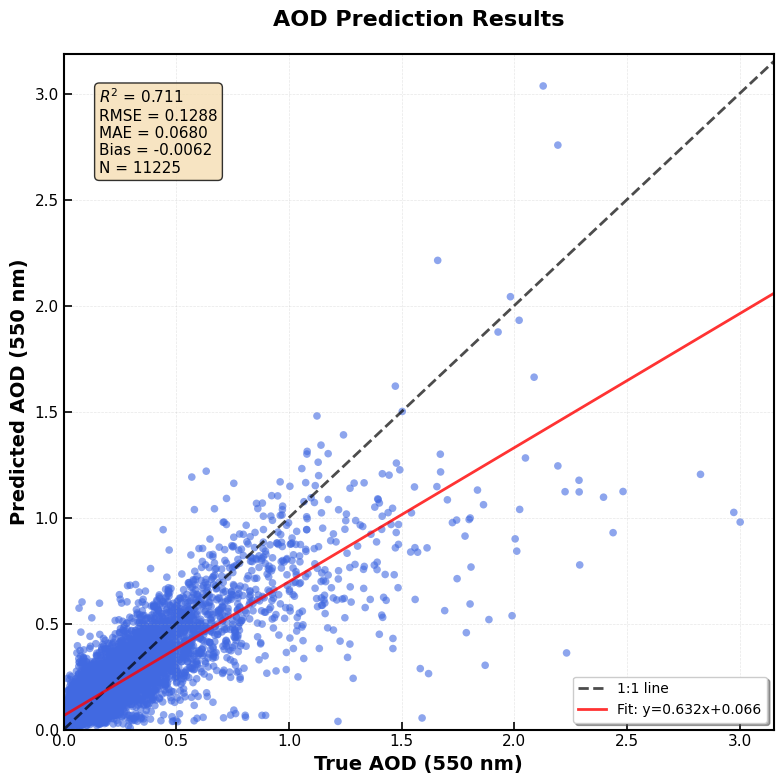

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

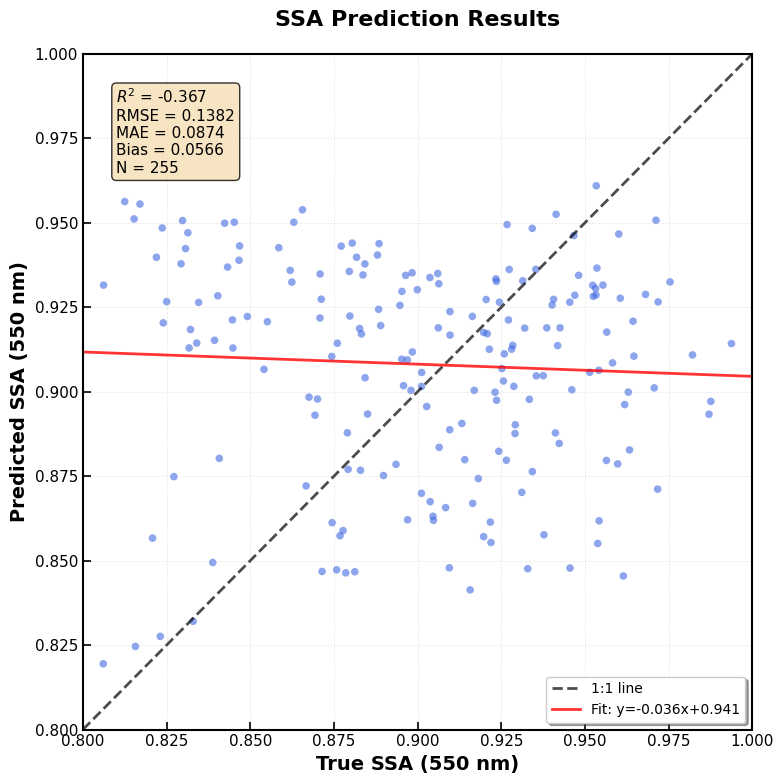

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

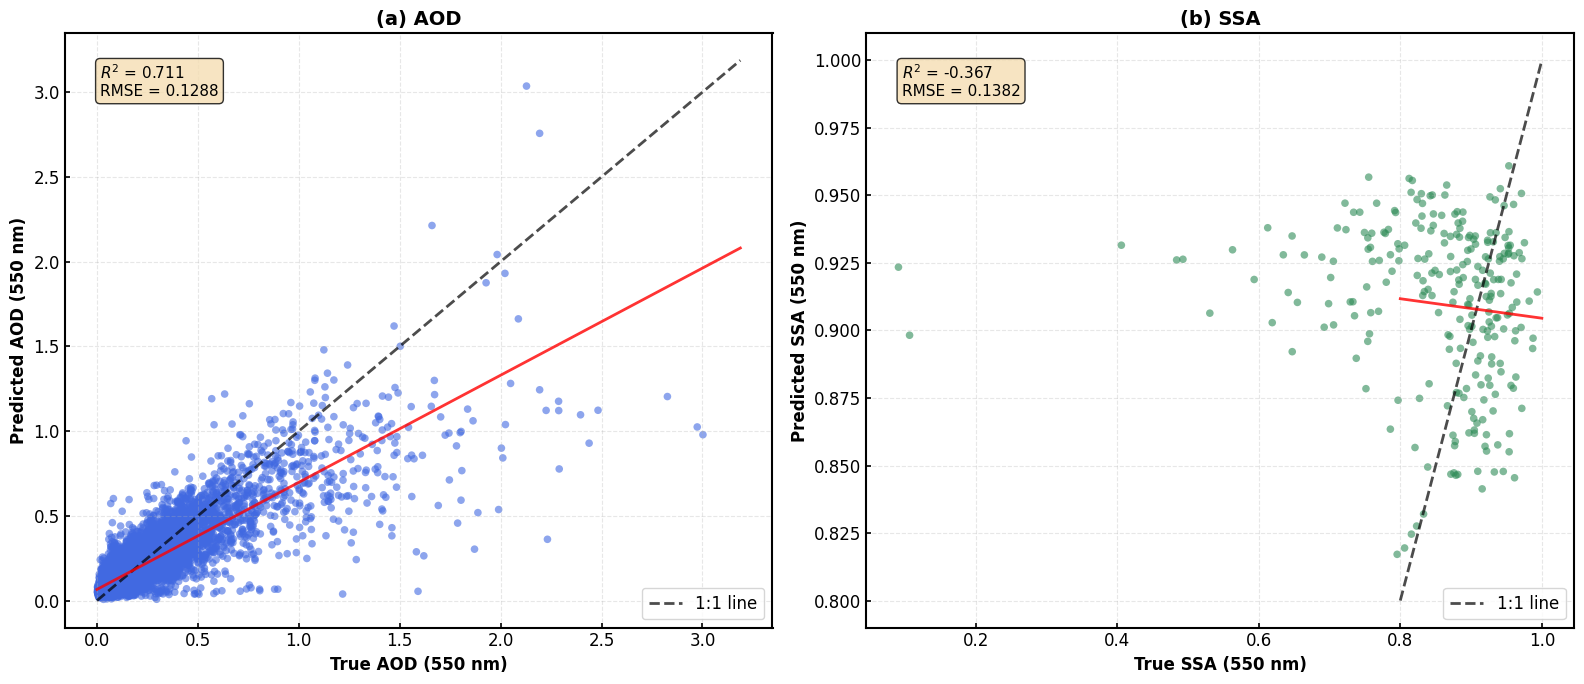

In [13]:
# ==============================================================================
# 7. 可视化结果 - 专业版
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 读取数据
df = pd.read_csv(OUTPUT_CSV_PATH)

# 设置专业绘图风格
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2

# 定义绘图函数
def plot_scatter_with_stats(x, y, xlabel, ylabel, title, save_path=None, xlim=None, ylim=None):
    """
    绘制带统计信息的散点图
    
    Parameters:
    -----------
    x, y : array-like
        真实值和预测值
    xlabel, ylabel : str
        x轴和y轴标签
    title : str
        图标题
    save_path : str, optional
        保存路径
    xlim, ylim : tuple, optional
        坐标轴范围
    """
    # 过滤无效数据
    mask = (x > 0) & (y > 0) & ~np.isnan(x) & ~np.isnan(y)
    x_clean = x[mask]
    y_clean = y[mask]
    
    # 计算统计指标
    r2 = r2_score(x_clean, y_clean)
    rmse = np.sqrt(mean_squared_error(x_clean, y_clean))
    mae = mean_absolute_error(x_clean, y_clean)
    bias = np.mean(y_clean - x_clean)
    
    # 线性拟合
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # 绘制散点图
    sc = ax.scatter(x_clean, y_clean, c='royalblue', alpha=0.6, s=30, edgecolors='none', rasterized=True)
    
    # 绘制1:1参考线
    lims = [min(ax.get_xlim(), ax.get_ylim()), max(ax.get_xlim(), ax.get_ylim())]
    if xlim is not None:
        lims = xlim
    elif ylim is not None:
        lims = ylim
    else:
        min_val = min(x_clean.min(), y_clean.min())
        max_val = max(x_clean.max(), y_clean.max())
        lims = [min_val, max_val]
    
    ax.plot(lims, lims, 'k--', linewidth=2, alpha=0.7, label='1:1 line')
    
    # 绘制拟合线
    x_fit = np.array(lims)
    y_fit = slope * x_fit + intercept
    ax.plot(x_fit, y_fit, 'r-', linewidth=2, alpha=0.8, label=f'Fit: y={slope:.3f}x+{intercept:.3f}')
    
    # 添加统计信息文本框
    stats_text = f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.4f}\nMAE = {mae:.4f}\nBias = {bias:.4f}\nN = {len(x_clean)}'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
            fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # 设置坐标轴
    ax.set_xlabel(xlabel, fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    
    # 设置坐标轴范围
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    
    # 设置刻度
    ax.tick_params(axis='both', which='major', labelsize=11, width=1.2, length=6)
    ax.tick_params(axis='both', which='minor', width=0.8, length=3)
    
    # 添加网格（可选）
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # 图例
    ax.legend(loc='lower right', fontsize=10, frameon=True, fancybox=True, shadow=True)
    
    # 紧凑布局
    plt.tight_layout()
    
    # # 保存图片
    # if save_path:
    #     plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    #     print(f"图片已保存至: {save_path}")
    
    plt.show()
    
    return fig, ax

# 绘制AOD预测结果
fig1, ax1 = plot_scatter_with_stats(
    x=df['AOD_550nm'],
    y=df['Pred_AOD_550nm'],
    xlabel='True AOD (550 nm)',
    ylabel='Predicted AOD (550 nm)',
    title='AOD Prediction Results',
    save_path='AOD_prediction_scatter.png',
    xlim=[0, df['AOD_550nm'].max() * 1.05],
    ylim=[0, df['Pred_AOD_550nm'].max() * 1.05]
)

# 绘制SSA预测结果
# 过滤SSA有效值（通常SSA在0-1之间）
df_ssa = df[(df['SSA_550nm'] > 0) & (df['SSA_550nm'] < 1) & 
            (df['Pred_SSA_550nm'] > 0) & (df['Pred_SSA_550nm'] < 1)]

fig2, ax2 = plot_scatter_with_stats(
    x=df_ssa['SSA_550nm'],
    y=df_ssa['Pred_SSA_550nm'],
    xlabel='True SSA (550 nm)',
    ylabel='Predicted SSA (550 nm)',
    title='SSA Prediction Results',
    save_path='SSA_prediction_scatter.png',
    xlim=[0.8, 1.0],  # SSA典型范围
    ylim=[0.8, 1.0]
)

# ==============================================================================
# 可选：组合图（AOD和SSA并排显示）
# ==============================================================================
def plot_combined_results(df_aod, df_ssa):
    """绘制AOD和SSA预测结果的组合图"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # 左图：AOD
    ax = axes[0]
    mask_aod = (df_aod['AOD_550nm'] > 0) & (df_aod['Pred_AOD_550nm'] > 0)
    x_aod = df_aod['AOD_550nm'][mask_aod]
    y_aod = df_aod['Pred_AOD_550nm'][mask_aod]
    
    r2_aod = r2_score(x_aod, y_aod)
    rmse_aod = np.sqrt(mean_squared_error(x_aod, y_aod))
    
    ax.scatter(x_aod, y_aod, c='royalblue', alpha=0.6, s=30, edgecolors='none')
    lims = [0, max(x_aod.max(), y_aod.max()) * 1.05]
    ax.plot(lims, lims, 'k--', linewidth=2, alpha=0.7, label='1:1 line')
    
    slope, intercept = np.polyfit(x_aod, y_aod, 1)
    ax.plot(lims, slope*np.array(lims)+intercept, 'r-', linewidth=2, alpha=0.8)
    
    ax.text(0.05, 0.95, f'$R^2$ = {r2_aod:.3f}\nRMSE = {rmse_aod:.4f}',
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    ax.set_xlabel('True AOD (550 nm)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Predicted AOD (550 nm)', fontsize=12, fontweight='bold')
    ax.set_title('(a) AOD', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # 右图：SSA
    ax = axes[1]
    mask_ssa = (df_ssa['SSA_550nm'] > 0) & (df_ssa['SSA_550nm'] < 1) & \
               (df_ssa['Pred_SSA_550nm'] > 0) & (df_ssa['Pred_SSA_550nm'] < 1)
    x_ssa = df_ssa['SSA_550nm'][mask_ssa]
    y_ssa = df_ssa['Pred_SSA_550nm'][mask_ssa]
    
    r2_ssa = r2_score(x_ssa, y_ssa)
    rmse_ssa = np.sqrt(mean_squared_error(x_ssa, y_ssa))
    
    ax.scatter(x_ssa, y_ssa, c='seagreen', alpha=0.6, s=30, edgecolors='none')
    lims = [0.8, 1.0]
    ax.plot(lims, lims, 'k--', linewidth=2, alpha=0.7, label='1:1 line')
    
    slope, intercept = np.polyfit(x_ssa, y_ssa, 1)
    ax.plot(lims, slope*np.array(lims)+intercept, 'r-', linewidth=2, alpha=0.8)
    
    ax.text(0.05, 0.95, f'$R^2$ = {r2_ssa:.3f}\nRMSE = {rmse_ssa:.4f}',
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    ax.set_xlabel('True SSA (550 nm)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Predicted SSA (550 nm)', fontsize=12, fontweight='bold')
    ax.set_title('(b) SSA', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    #plt.savefig('combined_prediction_results.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

# 调用组合图
plot_combined_results(df, df)